# Anomaly Detection in Congressional Stock Trading
## Master's Thesis - Big Data & Machine Learning
### Universidad de San Andres

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

COLORS = {'normal': '#3498DB', 'anomaly': '#E74C3C', 'dem': '#3498DB', 'rep': '#E74C3C', 'primary': '#2C3E50', 'secondary': '#7F8C8D'}
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

INPUT_PATH = r'C:\Users\sebib\Documents\GitHub\US_Congress\data\congress_trades\congress_trades_anomaly_features.parquet'
OUTPUT_DIR = r'C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('='*70)
print('ANOMALY DETECTION IN CONGRESSIONAL STOCK TRADING')
print('='*70)

ANOMALY DETECTION IN CONGRESSIONAL STOCK TRADING


## 1. Data Loading

In [2]:
df = pd.read_parquet(INPUT_PATH)
print(f'Loaded: {len(df):,} trades, {len(df.columns)} columns')

Loaded: 99,609 trades, 168 columns


In [3]:
FEATURES_POINT = ['disclosure_delay', 'trade_size_mid', 'is_contrarian', 'is_large_trade', 'is_purchase', 'momentum_5d', 'momentum_60d', 'realized_vol_30d', 'volume_ratio_30d', 'abnormal_volume_30d', 'amihud_illiq_20d', 'beta_252d', 'is_regulated_sector', 'is_defense_sector', 'committee_sector_match']
FEATURES_CONTEXTUAL = ['days_since_last_trade', 'trade_size_vs_history', 'is_new_ticker', 'politician_rolling_win_rate', 'politician_6m_trade_count', 'is_new_sector', 'politician_sector_hhi']
FEATURES_COLLECTIVE = ['n_politicians_same_ticker_window', 'n_politicians_same_direction', 'n_same_committee_same_ticker', 'n_same_party_same_ticker', 'is_bipartisan_coordination', 'coordination_ratio', 'n_politicians_same_sector_week']

FEATURES_POINT = [f for f in FEATURES_POINT if f in df.columns]
FEATURES_CONTEXTUAL = [f for f in FEATURES_CONTEXTUAL if f in df.columns]
FEATURES_COLLECTIVE = [f for f in FEATURES_COLLECTIVE if f in df.columns]
FEATURES_ALL = FEATURES_POINT + FEATURES_CONTEXTUAL + FEATURES_COLLECTIVE
print(f'Total features: {len(FEATURES_ALL)}')

Total features: 29


In [4]:
df_model = df.dropna(subset=FEATURES_ALL).copy()
for col in FEATURES_ALL:
    df_model[col] = df_model[col].replace([np.inf, -np.inf], np.nan)
    q01, q99 = df_model[col].quantile([0.01, 0.99])
    df_model[col] = df_model[col].clip(q01, q99)
df_model = df_model.dropna(subset=FEATURES_ALL)
print(f'Final sample: {len(df_model):,} trades')
scaler = RobustScaler()

Final sample: 80,097 trades


## 2A. Point Anomalies

In [5]:
CONTAMINATION = 0.05
X_point = scaler.fit_transform(df_model[FEATURES_POINT])

print('Training Isolation Forest...')
clf_if = IsolationForest(contamination=CONTAMINATION, n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
df_model['anomaly_if'] = (clf_if.fit_predict(X_point) == -1).astype(int)
df_model['score_if_raw'] = -clf_if.score_samples(X_point)
print(f'   IF anomalies: {df_model["anomaly_if"].sum():,}')

print('Training One-Class SVM...')
idx_sample = np.random.choice(len(X_point), min(20000, len(X_point)), replace=False)
clf_svm = OneClassSVM(nu=CONTAMINATION, kernel='rbf', gamma='auto')
clf_svm.fit(X_point[idx_sample])
df_model['anomaly_svm'] = (clf_svm.predict(X_point) == -1).astype(int)
df_model['score_svm_raw'] = -clf_svm.decision_function(X_point)
print(f'   SVM anomalies: {df_model["anomaly_svm"].sum():,}')

Training Isolation Forest...
   IF anomalies: 4,005
Training One-Class SVM...
   SVM anomalies: 7,332


## 2B. Contextual Anomalies

In [6]:
print('Computing contextual anomalies (LOF per politician)...')
FEATURES_FOR_LOF = [f for f in FEATURES_POINT + FEATURES_CONTEXTUAL if f in df_model.columns]
df_model['anomaly_lof_contextual'] = 0
df_model['score_lof_contextual'] = 0.0

for bioguide_id, group in df_model.groupby('BioGuideID'):
    if len(group) < 20:
        continue
    idx = group.index
    X_pol = RobustScaler().fit_transform(group[FEATURES_FOR_LOF].values)
    n_neighbors = min(20, len(group) // 2)
    if n_neighbors < 5:
        continue
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=CONTAMINATION)
    labels = lof.fit_predict(X_pol)
    df_model.loc[idx, 'anomaly_lof_contextual'] = (labels == -1).astype(int)
    df_model.loc[idx, 'score_lof_contextual'] = -lof.negative_outlier_factor_

print(f'   Contextual anomalies: {df_model["anomaly_lof_contextual"].sum():,}')

Computing contextual anomalies (LOF per politician)...
   Contextual anomalies: 4,040


## 2C. Collective Anomalies

In [7]:
print('Computing collective anomalies...')
df_model['anomaly_collective_rules'] = ((df_model['n_politicians_same_ticker_window'] >= 3) & (df_model['coordination_ratio'] >= 0.7) & ((df_model['is_bipartisan_coordination'] == 1) | (df_model['n_same_committee_same_ticker'] >= 2))).astype(int)

X_coll = scaler.fit_transform(df_model[FEATURES_COLLECTIVE])
lof_coll = LocalOutlierFactor(n_neighbors=50, contamination=CONTAMINATION)
df_model['anomaly_lof_collective'] = (lof_coll.fit_predict(X_coll) == -1).astype(int)
df_model['score_lof_collective'] = -lof_coll.negative_outlier_factor_

df_model['anomaly_collective'] = ((df_model['anomaly_collective_rules'] == 1) | (df_model['anomaly_lof_collective'] == 1)).astype(int)
print(f'   Collective anomalies: {df_model["anomaly_collective"].sum():,}')

Computing collective anomalies...
   Collective anomalies: 4,368


## 3. Ensemble

In [8]:
anomaly_columns = ['anomaly_if', 'anomaly_svm', 'anomaly_lof_contextual', 'anomaly_collective']
df_model['anomaly_vote_count'] = df_model[anomaly_columns].sum(axis=1)
df_model['anomaly_consensus_2'] = (df_model['anomaly_vote_count'] >= 2).astype(int)

for col in ['score_if_raw', 'score_svm_raw', 'score_lof_contextual', 'score_lof_collective']:
    df_model[f'{col}_norm'] = MinMaxScaler().fit_transform(df_model[[col]])
df_model['anomaly_score_ensemble'] = df_model[[f'{c}_norm' for c in ['score_if_raw', 'score_svm_raw', 'score_lof_contextual', 'score_lof_collective']]].mean(axis=1)

print(f'Consensus >=2: {df_model["anomaly_consensus_2"].sum():,} ({df_model["anomaly_consensus_2"].mean():.1%})')

Consensus >=2: 4,209 (5.3%)


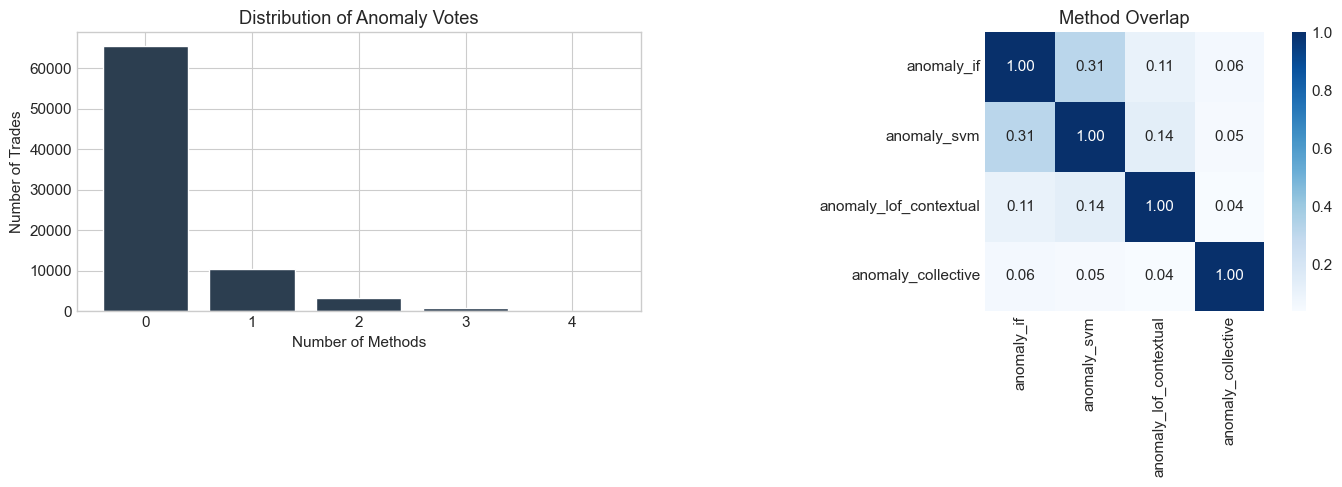

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vote_counts = df_model['anomaly_vote_count'].value_counts().sort_index()
axes[0].bar(vote_counts.index, vote_counts.values, color=COLORS['primary'], edgecolor='white')
axes[0].set_xlabel('Number of Methods')
axes[0].set_ylabel('Number of Trades')
axes[0].set_title('Distribution of Anomaly Votes')

overlap = pd.DataFrame(index=anomaly_columns, columns=anomaly_columns, dtype=float)
for c1 in anomaly_columns:
    for c2 in anomaly_columns:
        both = ((df_model[c1]==1) & (df_model[c2]==1)).sum()
        either = ((df_model[c1]==1) | (df_model[c2]==1)).sum()
        overlap.loc[c1,c2] = both/either if either>0 else 0
sns.heatmap(overlap.astype(float), annot=True, fmt='.2f', cmap='Blues', ax=axes[1], square=True)
axes[1].set_title('Method Overlap')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_01_method_agreement.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_01_method_agreement.pdf', bbox_inches='tight', facecolor='white')
plt.show()

## 4. CAR Validation

In [10]:
ANOMALY_COL = 'anomaly_consensus_2'
CAR_COLS = [c for c in ['car_ff3_30d', 'car_ff3_60d', 'car_ff3_90d'] if c in df_model.columns]

print('='*70)
print('CAR COMPARISON: Normal vs Anomalous')
print('='*70)
car_results = []
for car_col in CAR_COLS:
    normal = df_model[df_model[ANOMALY_COL]==0][car_col].dropna()
    anomaly = df_model[df_model[ANOMALY_COL]==1][car_col].dropna()
    diff = anomaly.mean() - normal.mean()
    t_stat, p_val = ttest_ind(anomaly, normal)
    pooled_std = np.sqrt((normal.std()**2 + anomaly.std()**2)/2)
    d = diff/pooled_std if pooled_std>0 else 0
    car_results.append({'CAR': car_col, 'Mean_Normal': normal.mean(), 'Mean_Anomaly': anomaly.mean(), 'Difference': diff, 'Cohens_d': d, 'p_value': p_val})
    sig = '***' if p_val<0.01 else '**' if p_val<0.05 else '*' if p_val<0.1 else ''
    print(f'{car_col}: Normal={normal.mean():.4f} Anomaly={anomaly.mean():.4f} Diff={diff:.4f} p={p_val:.4f} {sig}')
car_results_df = pd.DataFrame(car_results)

CAR COMPARISON: Normal vs Anomalous
car_ff3_30d: Normal=-0.0012 Anomaly=0.0124 Diff=0.0135 p=0.0000 ***
car_ff3_60d: Normal=-0.0022 Anomaly=0.0200 Diff=0.0222 p=0.0000 ***
car_ff3_90d: Normal=-0.0039 Anomaly=0.0213 Diff=0.0252 p=0.0000 ***


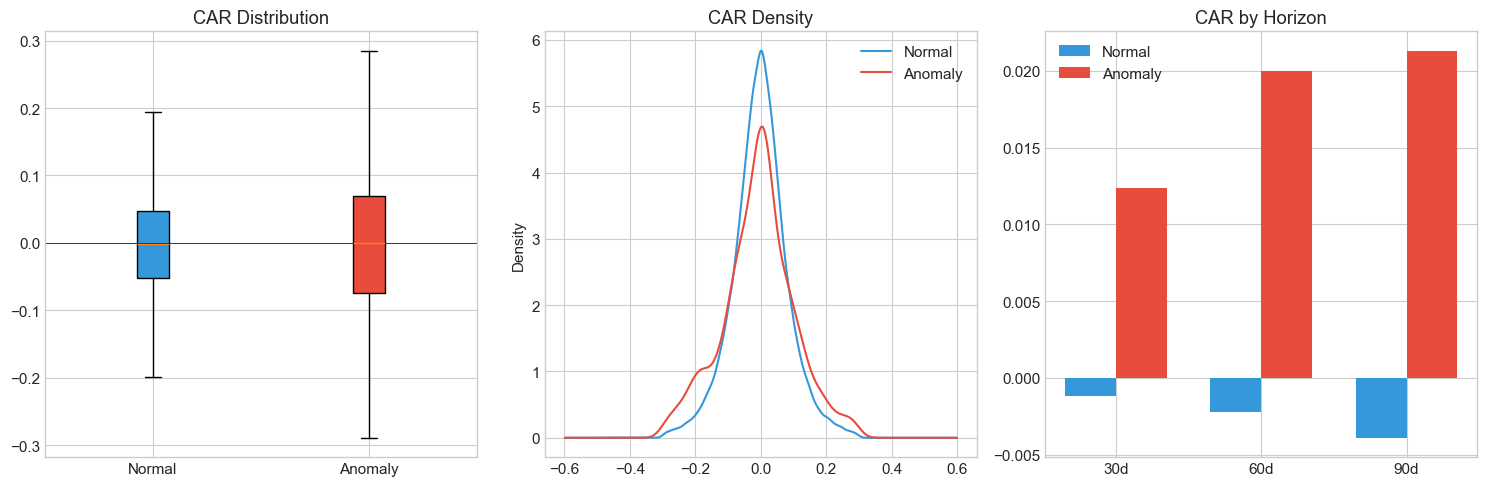

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
main_car = 'car_ff3_30d'
normal_car = df_model[df_model[ANOMALY_COL]==0][main_car].dropna()
anomaly_car = df_model[df_model[ANOMALY_COL]==1][main_car].dropna()

bp = axes[0].boxplot([normal_car, anomaly_car], labels=['Normal', 'Anomaly'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor(COLORS['normal'])
bp['boxes'][1].set_facecolor(COLORS['anomaly'])
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('CAR Distribution')

normal_car[(normal_car>=-0.3)&(normal_car<=0.3)].plot.kde(ax=axes[1], color=COLORS['normal'], label='Normal')
anomaly_car[(anomaly_car>=-0.3)&(anomaly_car<=0.3)].plot.kde(ax=axes[1], color=COLORS['anomaly'], label='Anomaly')
axes[1].legend()
axes[1].set_title('CAR Density')

horizons = ['30d', '60d', '90d']
mn = [df_model[df_model[ANOMALY_COL]==0][f'car_ff3_{h}'].mean() for h in horizons if f'car_ff3_{h}' in df_model.columns]
ma = [df_model[df_model[ANOMALY_COL]==1][f'car_ff3_{h}'].mean() for h in horizons if f'car_ff3_{h}' in df_model.columns]
x = np.arange(len(mn))
axes[2].bar(x-0.175, mn, 0.35, label='Normal', color=COLORS['normal'])
axes[2].bar(x+0.175, ma, 0.35, label='Anomaly', color=COLORS['anomaly'])
axes[2].set_xticks(x)
axes[2].set_xticklabels(horizons[:len(mn)])
axes[2].legend()
axes[2].set_title('CAR by Horizon')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_02_car_validation.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_02_car_validation.pdf', bbox_inches='tight', facecolor='white')
plt.show()

## 5. Profiling

In [12]:
# 5.1 By Politician
politician_stats = df_model.groupby(['BioGuideID', 'Name', 'Party', 'Chamber']).agg({ANOMALY_COL: ['sum', 'mean'], 'trade_id': 'count', 'car_ff3_30d': 'mean'}).reset_index()
politician_stats.columns = ['BioGuideID', 'Name', 'Party', 'Chamber', 'Anomaly_Count', 'Anomaly_Rate', 'Total_Trades', 'Avg_CAR']
politician_stats = politician_stats[politician_stats['Total_Trades'] >= 20].sort_values('Anomaly_Rate', ascending=False)
print('Top 15 by Anomaly Rate:')
print(politician_stats.head(15)[['Name', 'Party', 'Anomaly_Rate', 'Total_Trades', 'Avg_CAR']].to_string(index=False))

Top 15 by Anomaly Rate:
            Name Party  Anomaly_Rate  Total_Trades   Avg_CAR
    Nancy Pelosi     D      0.455882           136  0.007334
     Smith, Tina     D      0.409091            22  0.043463
   Daniel Meuser     R      0.405797            69  0.010876
Moody, Ashley B.     R      0.333333            21  0.000106
      Brian Mast     R      0.322581            62  0.015869
     Sheri Biggs     R      0.305556            72 -0.007021
  Tom Malinowski     D      0.294118           204 -0.021476
  Adam Kinzinger     R      0.290323            31 -0.042987
 Loeffler, Kelly     R      0.289157           249 -0.013073
      Mark Green     R      0.286585           164 -0.068154
  James E. Banks     R      0.280000            25 -0.075378
   Mark Dr Green     R      0.269767           215  0.006870
       Tim Moore     R      0.269461           167  0.004392
 Daniel Crenshaw     R      0.250000            28 -0.021988
   Thomas Suozzi     D      0.242991           535  0.010401


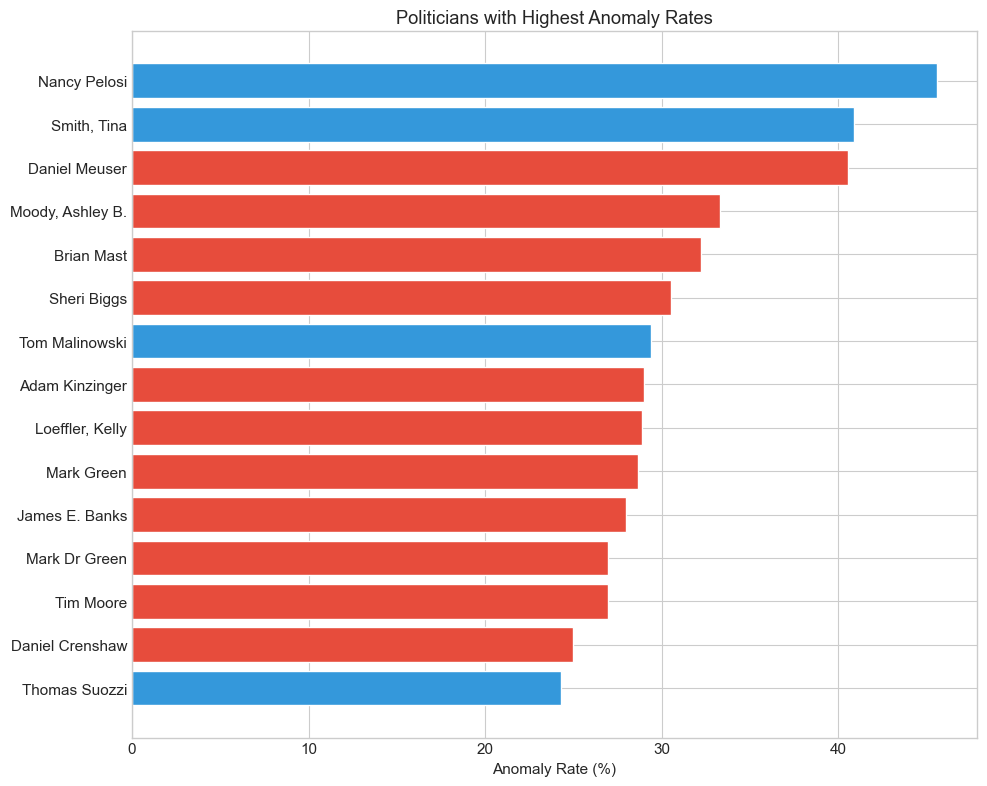

In [13]:
top15 = politician_stats.head(15)
fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLORS['dem'] if p=='D' else COLORS['rep'] if p=='R' else COLORS['secondary'] for p in top15['Party']]
ax.barh(range(len(top15)), top15['Anomaly_Rate']*100, color=colors, edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Name'])
ax.set_xlabel('Anomaly Rate (%)')
ax.set_title('Politicians with Highest Anomaly Rates')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_03_top_politicians.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_03_top_politicians.pdf', bbox_inches='tight', facecolor='white')
plt.show()

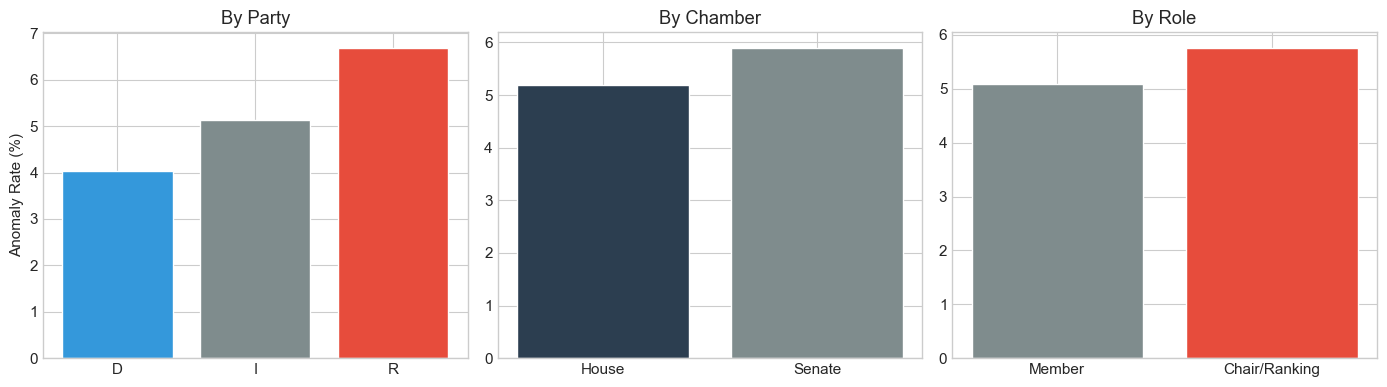

In [14]:
# 5.2 By Party/Chamber
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
party_data = df_model.groupby('Party')[ANOMALY_COL].mean()*100
axes[0].bar(party_data.index, party_data.values, color=[COLORS['dem'], COLORS['secondary'], COLORS['rep']][:len(party_data)], edgecolor='white')
axes[0].set_ylabel('Anomaly Rate (%)')
axes[0].set_title('By Party')

chamber_data = df_model.groupby('Chamber')[ANOMALY_COL].mean()*100
axes[1].bar(chamber_data.index, chamber_data.values, color=[COLORS['primary'], COLORS['secondary']], edgecolor='white')
axes[1].set_title('By Chamber')

role_data = df_model.groupby('is_chair_or_ranking')[ANOMALY_COL].mean()*100
axes[2].bar(['Member', 'Chair/Ranking'], role_data.values, color=[COLORS['secondary'], COLORS['anomaly']], edgecolor='white')
axes[2].set_title('By Role')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_04_anomaly_by_group.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_04_anomaly_by_group.pdf', bbox_inches='tight', facecolor='white')
plt.show()

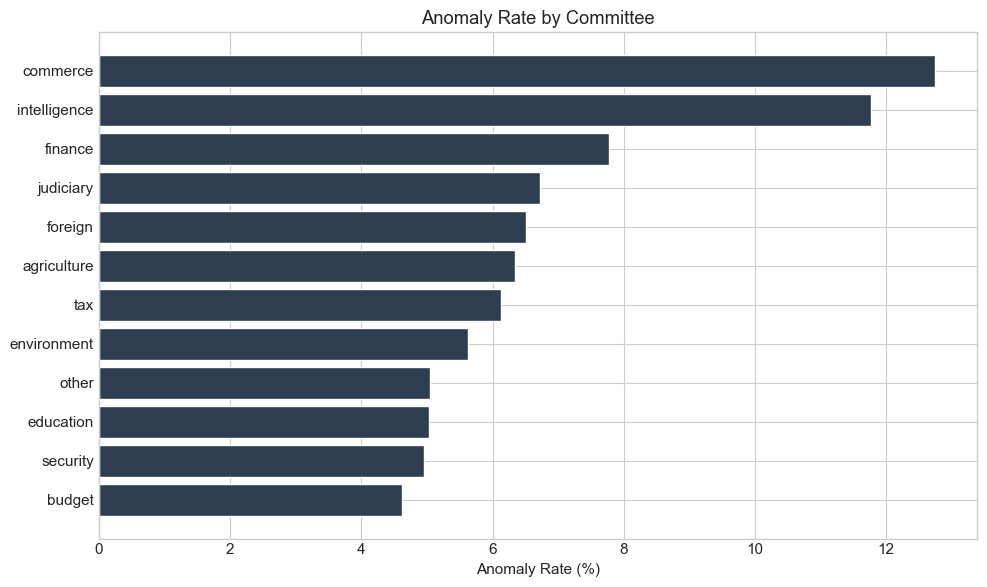

In [15]:
# 5.3 By Committee
if 'committee_topic' in df_model.columns:
    comm_stats = df_model.groupby('committee_topic')[ANOMALY_COL].agg(['sum', 'mean', 'count'])
    comm_stats.columns = ['Anomalies', 'Rate', 'Total']
    comm_stats = comm_stats[comm_stats['Total']>=100].sort_values('Rate', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_comm = comm_stats.head(12)
    ax.barh(range(len(top_comm)), top_comm['Rate']*100, color=COLORS['primary'], edgecolor='white')
    ax.set_yticks(range(len(top_comm)))
    ax.set_yticklabels(top_comm.index)
    ax.set_xlabel('Anomaly Rate (%)')
    ax.set_title('Anomaly Rate by Committee')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_05_anomaly_by_committee.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{OUTPUT_DIR}/fig_05_anomaly_by_committee.pdf', bbox_inches='tight', facecolor='white')
    plt.show()

Anomaly Rate by Sector:
                        Anomalies    Rate  Total
sector                                          
Energy                        302  0.0697   4332
Technology                    965  0.0690  13983
Communication Services        352  0.0673   5230
Industrials                   575  0.0607   9474
Financial Services            568  0.0487  11654
Consumer Cyclical             439  0.0458   9589
Healthcare                    370  0.0368  10065
Utilities                      59  0.0360   1638
Consumer Defensive            156  0.0276   5657
Basic Materials                82  0.0254   3227
Real Estate                    60  0.0212   2834


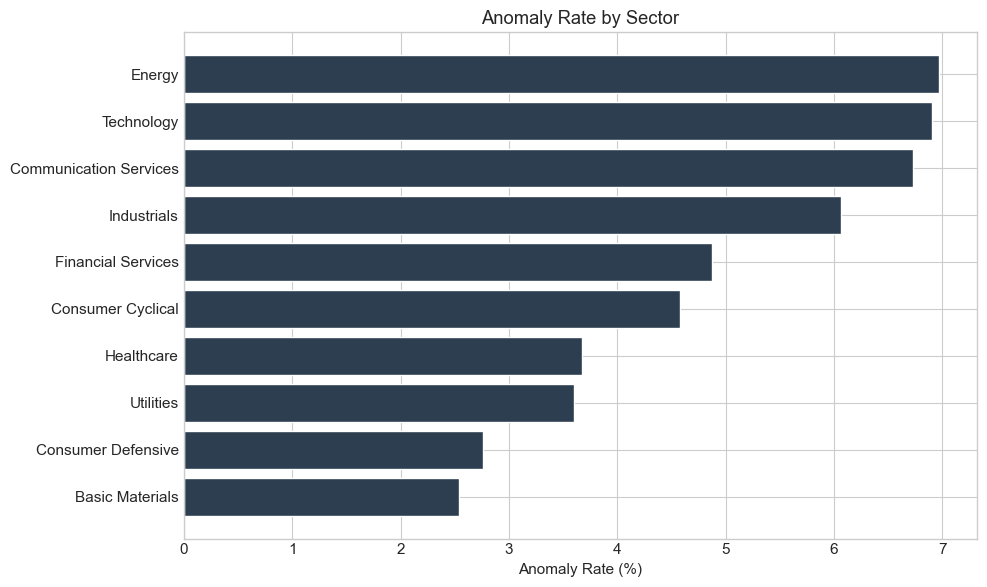

In [16]:
# 5.4 By Sector
if 'sector' in df_model.columns:
    sector_stats = df_model.groupby('sector')[ANOMALY_COL].agg(['sum', 'mean', 'count'])
    sector_stats.columns = ['Anomalies', 'Rate', 'Total']
    sector_stats = sector_stats[sector_stats['Total']>=100].sort_values('Rate', ascending=False)
    print('Anomaly Rate by Sector:')
    print(sector_stats.round(4))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_sec = sector_stats.head(10)
    ax.barh(range(len(top_sec)), top_sec['Rate']*100, color=COLORS['primary'], edgecolor='white')
    ax.set_yticks(range(len(top_sec)))
    ax.set_yticklabels(top_sec.index)
    ax.set_xlabel('Anomaly Rate (%)')
    ax.set_title('Anomaly Rate by Sector')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig_05b_anomaly_by_sector.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.savefig(f'{OUTPUT_DIR}/fig_05b_anomaly_by_sector.pdf', bbox_inches='tight', facecolor='white')
    plt.show()

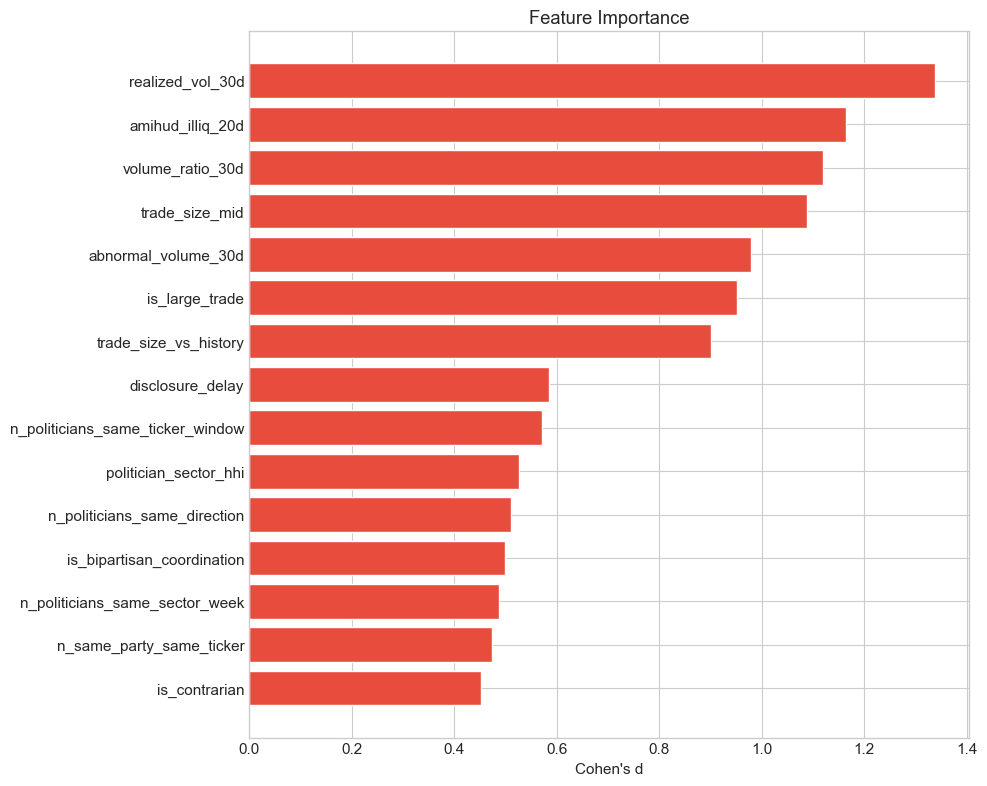

In [17]:
# 5.5 Feature importance
feat_comp = []
for f in FEATURES_ALL:
    n_mean = df_model[df_model[ANOMALY_COL]==0][f].mean()
    a_mean = df_model[df_model[ANOMALY_COL]==1][f].mean()
    std = df_model[f].std()
    d = (a_mean - n_mean)/std if std>0 else 0
    feat_comp.append({'Feature': f, 'Cohens_d': d})
feat_df = pd.DataFrame(feat_comp).sort_values('Cohens_d', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top_f = feat_df.head(15)
colors = [COLORS['anomaly'] if d>0 else COLORS['normal'] for d in top_f['Cohens_d']]
ax.barh(range(len(top_f)), top_f['Cohens_d'], color=colors, edgecolor='white')
ax.set_yticks(range(len(top_f)))
ax.set_yticklabels(top_f['Feature'])
ax.set_xlabel("Cohen's d")
ax.set_title('Feature Importance')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_06_feature_importance.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_06_feature_importance.pdf', bbox_inches='tight', facecolor='white')
plt.show()

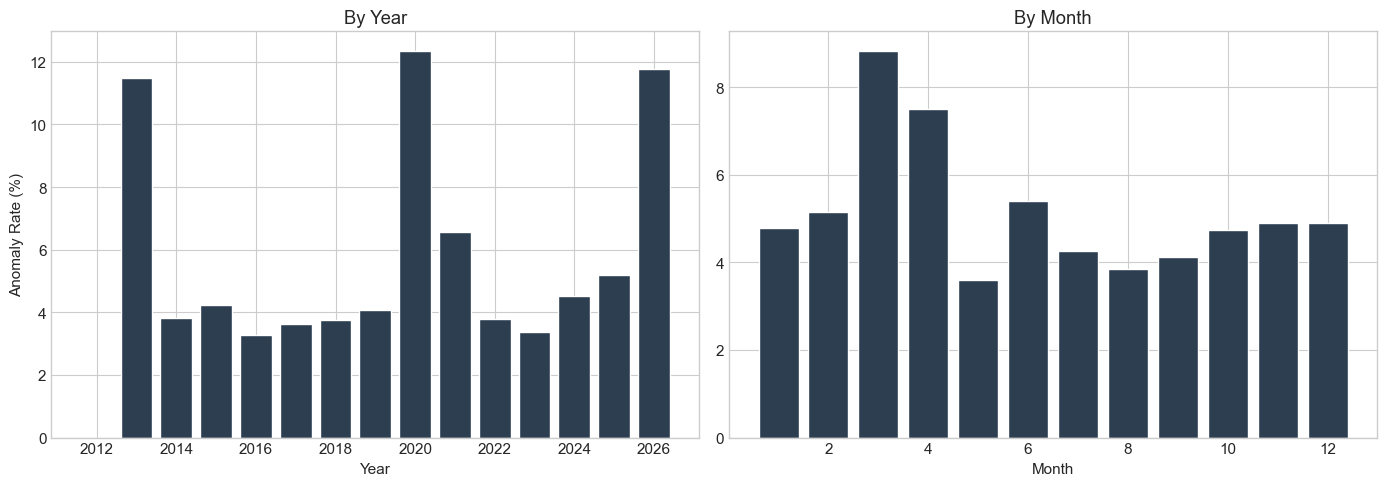

In [18]:
# 5.6 Temporal
df_model['trade_year'] = df_model['trade_date'].dt.year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_data = df_model.groupby('trade_year')[ANOMALY_COL].mean()*100
axes[0].bar(year_data.index, year_data.values, color=COLORS['primary'], edgecolor='white')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Anomaly Rate (%)')
axes[0].set_title('By Year')

if 'trade_month' in df_model.columns:
    month_data = df_model.groupby('trade_month')[ANOMALY_COL].mean()*100
    axes[1].bar(month_data.index, month_data.values, color=COLORS['primary'], edgecolor='white')
    axes[1].set_xlabel('Month')
    axes[1].set_title('By Month')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_07_temporal_patterns.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_07_temporal_patterns.pdf', bbox_inches='tight', facecolor='white')
plt.show()

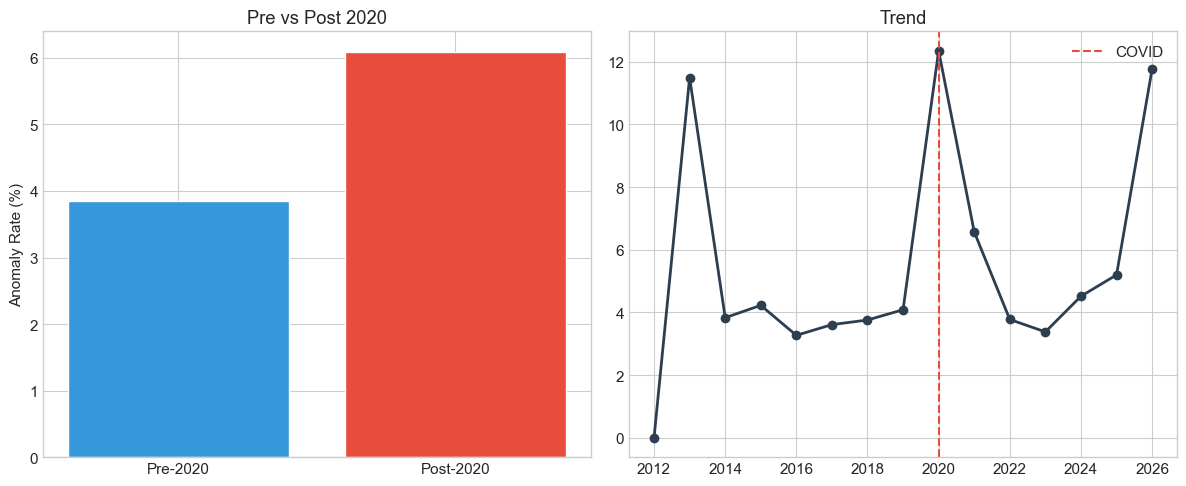

In [19]:
# 5.7 Pre vs Post 2020
df_model['post_2020'] = (df_model['trade_year'] >= 2020).astype(int)
pre = df_model[df_model['post_2020']==0][ANOMALY_COL].mean()
post = df_model[df_model['post_2020']==1][ANOMALY_COL].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(['Pre-2020', 'Post-2020'], [pre*100, post*100], color=[COLORS['normal'], COLORS['anomaly']], edgecolor='white')
axes[0].set_ylabel('Anomaly Rate (%)')
axes[0].set_title('Pre vs Post 2020')

year_trend = df_model.groupby('trade_year')[ANOMALY_COL].mean()*100
axes[1].plot(year_trend.index, year_trend.values, marker='o', color=COLORS['primary'], linewidth=2)
axes[1].axvline(2020, color=COLORS['anomaly'], linestyle='--', label='COVID')
axes[1].legend()
axes[1].set_title('Trend')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig_08_pre_post_2020.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(f'{OUTPUT_DIR}/fig_08_pre_post_2020.pdf', bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
# 5.8 Robustness
print('Robustness Check')
print('='*70)
X_robust = scaler.fit_transform(df_model[FEATURES_POINT])
for cont in [0.03, 0.05, 0.07, 0.10]:
    clf = IsolationForest(contamination=cont, n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    labels = clf.fit_predict(X_robust) == -1
    car_n = df_model.loc[~labels, 'car_ff3_30d'].mean()
    car_a = df_model.loc[labels, 'car_ff3_30d'].mean()
    print(f'Cont={cont:.0%}: N_anom={labels.sum():,} CAR_normal={car_n:.4f} CAR_anom={car_a:.4f} Diff={car_a-car_n:.4f}')

Robustness Check
Cont=3%: N_anom=2,403 CAR_normal=-0.0011 CAR_anom=0.0207 Diff=0.0218
Cont=5%: N_anom=4,004 CAR_normal=-0.0014 CAR_anom=0.0183 Diff=0.0198
Cont=7%: N_anom=5,607 CAR_normal=-0.0016 CAR_anom=0.0150 Diff=0.0167
Cont=10%: N_anom=8,010 CAR_normal=-0.0016 CAR_anom=0.0099 Diff=0.0115


## 6. Export

In [21]:
out_cols = ['trade_id', 'BioGuideID', 'Name', 'Party', 'Chamber', 'Ticker', 'trade_date', 'Transaction', 'Trade_Size_USD', 'sector', 'anomaly_if', 'anomaly_svm', 'anomaly_lof_contextual', 'anomaly_collective', 'anomaly_vote_count', 'anomaly_consensus_2', 'anomaly_score_ensemble', 'car_ff3_30d', 'car_ff3_60d', 'car_ff3_90d']
out_cols = [c for c in out_cols if c in df_model.columns]
df_model[out_cols].to_csv(f'{OUTPUT_DIR}/anomaly_detection_results.csv', index=False)
politician_stats.to_csv(f'{OUTPUT_DIR}/politician_anomaly_summary.csv', index=False)
car_results_df.to_csv(f'{OUTPUT_DIR}/car_validation_results.csv', index=False)
print(f'Saved to {OUTPUT_DIR}')

Saved to C:\Users\sebib\Documents\GitHub\US_Congress\Parte_2\Anomaly_Detection


In [22]:
print('\n' + '='*70)
print('SUMMARY')
print('='*70)
print(f'Total trades: {len(df_model):,}')
print(f'Anomalies (>=2 methods): {df_model["anomaly_consensus_2"].sum():,} ({df_model["anomaly_consensus_2"].mean():.1%})')
print(f'CAR Normal: {df_model[df_model["anomaly_consensus_2"]==0]["car_ff3_30d"].mean():.4f}')
print(f'CAR Anomaly: {df_model[df_model["anomaly_consensus_2"]==1]["car_ff3_30d"].mean():.4f}')


SUMMARY
Total trades: 80,097
Anomalies (>=2 methods): 4,209 (5.3%)
CAR Normal: -0.0012
CAR Anomaly: 0.0124
